当前模式：局部视图。共保留 21 个目标蛋白。
✅ 已成功提取 678 条 GO 关联记录，保存至: C:\Users\Administrator\Desktop\target_go_names.xlsx


<Figure size 800x840 with 0 Axes>

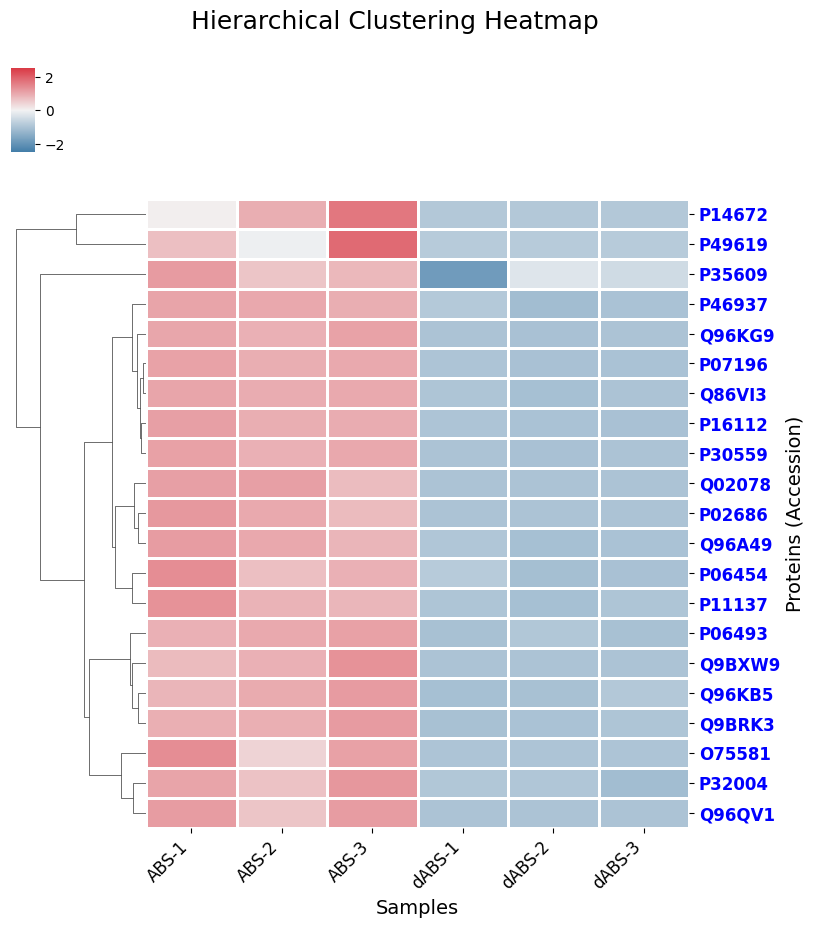

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
import re  # 🌟 新增：引入正则库用于清洗GO名字

# ==================== ⭐ 核心控制开关 ⭐ ====================
# True  -> 只画标记的名单蛋白（格子清晰，带白线，适合看局部），并导出对应的 GO 名单
# False -> 画全部 615 个蛋白（开启防重叠引线标注，目标蛋白高亮悬浮，适合看全局）
ONLY_SHOW_TARGETS = True 
# ========================================================

# ==================== 第 1 步：读取与清洗数据 ====================
file_path = r"C:\Users\Administrator\Desktop\Light_Blue_Pink_Data_2.xlsx"
df = pd.read_excel(file_path)

mark_file = r"C:\Users\Administrator\Desktop\mxw_proteomics\biaojichudedanbai.xlsx"
df_mark = pd.read_excel(mark_file)

# 【关键修复1】使用 .str.strip() 去除 Excel 中可能存在的首尾隐形空格
target_proteins = df_mark['Accession_new'].dropna().astype(str).str.strip().tolist()
df['Accession'] = df['Accession'].astype(str).str.strip()

# 根据开关决定是否过滤数据
if ONLY_SHOW_TARGETS:
    df = df[df['Accession'].isin(target_proteins)].copy()
    print(f"当前模式：局部视图。共保留 {len(df)} 个目标蛋白。")
    
    # ==================== 🌟 新增：提取目标蛋白的 Accession 和 GO Name 并保存 🌟 ====================
    target_go_records = []
    
    # 总表里可能包含 GO 注释的列名
    go_columns = [
        'Gene Ontology (biological process)', 
        'Gene Ontology (cellular component)', 
        'Gene Ontology (molecular function)', 
        'Gene Ontology (GO)'
    ]
    
    # 遍历当前保留的每一个靶点蛋白
    for index, row in df.iterrows():
        acc = row['Accession']
        for col in go_columns:
            if col in df.columns and pd.notna(row[col]):
                # 按分号拆分同一列中的多个 GO
                terms = str(row[col]).split(';')
                for term in terms:
                    # 使用正则去掉形如 "[GO:0006412]" 的编号，只保留纯英文名字
                    clean_term = re.sub(r'\s*\[GO:\d+\]\s*', '', term).strip()
                    if clean_term:
                        # 将 Accession 和清洗后的 GO Name 存入记录字典
                        target_go_records.append({'Accession': acc, 'GO Name': clean_term})
                        
    # 转换为 DataFrame 并去重（防止不同GO列里出现重复的相同词条）
    go_export_df = pd.DataFrame(target_go_records).drop_duplicates()
    
    # 保存为 Excel 到桌面
    export_path = r"C:\Users\Administrator\Desktop\target_go_names.xlsx"
    go_export_df.to_excel(export_path, index=False)
    print(f"✅ 已成功提取 {len(go_export_df)} 条 GO 关联记录，保存至: {export_path}")
    # ==============================================================================================

else:
    print(f"当前模式：全局视图。共绘制 {len(df)} 个蛋白。")

# ==================== 第 2 步：Z-score 归一化处理 ====================
data_columns = ['ABS-1', 'ABS-2', 'ABS-3', 'dABS-1', 'dABS-2', 'dABS-3']
df_exp = df[data_columns]

# 归一化
df_zscore = df_exp.apply(zscore, axis=1)
df_zscore.index = df['Accession']

# ==================== 第 3 步：绘制层次聚类热图 ====================
cmap = sns.diverging_palette(240, 10, as_cmap=True)

if ONLY_SHOW_TARGETS:
    fig_w, fig_h = 8, max(6, len(df_zscore) * 0.4)
    grid_linewidth = 1
else:
    fig_w, fig_h = 12, 25
    grid_linewidth = 0

plt.figure(figsize=(fig_w, fig_h))

cg = sns.clustermap(
    df_zscore,
    method='ward',
    metric='euclidean',
    cmap=cmap,
    center=0,
    vmin=-2.5, vmax=2.5,
    figsize=(fig_w, fig_h),
    col_cluster=False,
    row_cluster=True,
    linewidths=grid_linewidth,
    linecolor='white',
    cbar_pos=(0.02, 0.85, 0.03, 0.1),
    yticklabels=True  # 【关键修复2】强制画出所有的标签，防止库自作主张删减
)

# ==================== 第 4 步：高亮标记与防重叠处理 ====================
ax = cg.ax_heatmap

if ONLY_SHOW_TARGETS:
    # 【局部模式】：不拥挤，直接把标签全部标蓝加粗
    for text in ax.get_yticklabels():
        text.set_color('blue')
        text.set_fontweight('bold')
        text.set_fontsize(12)
else:
    # 【全局模式】：数据太多必定拥挤，启动“防重叠引线”算法
    
    # 1. 隐藏自带的所有标签，同时记录它们的真实高度（Y坐标）
    y_dict = {}
    for tick_pos, text_obj in zip(ax.get_yticks(), ax.get_yticklabels()):
        prot_name = text_obj.get_text()
        y_dict[prot_name] = tick_pos
        text_obj.set_visible(False)  # 全部隐藏原带的文字，腾出干净的画布
        
    # 2. 提取我们要标蓝的目标蛋白，并按照高度从上到下排序
    y_orig_list = []
    text_list = []
    for prot in target_proteins:
        if prot in y_dict:
            y_orig_list.append(y_dict[prot])
            text_list.append(prot)
            
    sorted_pairs = sorted(zip(y_orig_list, text_list))
    y_orig_list = [p[0] for p in sorted_pairs]
    text_list = [p[1] for p in sorted_pairs]
    
    # 3. 智能排斥算法：计算新的Y坐标，防止文字堆叠
    y_new_list = np.array(y_orig_list, dtype=float)
    min_dist = 8.0  # ★ 最小安全间距
    
    for _ in range(500):
        moved = False
        for i in range(len(y_new_list) - 1):
            if y_new_list[i+1] - y_new_list[i] < min_dist:
                overlap = min_dist - (y_new_list[i+1] - y_new_list[i])
                y_new_list[i] -= overlap / 2.0
                y_new_list[i+1] += overlap / 2.0
                moved = True
        if not moved:
            break
            
    # 4. 用连线重新画出蓝色的蛋白名字
    x_edge = df_zscore.shape[1]  # 获取热图右边缘位置
    for y_orig, y_new, txt in zip(y_orig_list, y_new_list, text_list):
        ax.annotate(
            txt,
            xy=(x_edge, y_orig),               # 线条起点：指向热图对应的原始色块
            xytext=(x_edge + 0.2, y_new),      # 文字位置：经过排斥算法拉开后的新位置
            color='blue',
            fontsize=12,
            fontweight='bold',
            va='center',
            ha='left',
            annotation_clip=False,             # 允许画在坐标轴外面
            arrowprops=dict(
                arrowstyle="-",                # 引线样式（直线）
                color='black',                 # 引线颜色
                alpha=0.5,                     # 引线透明度
                lw=1.0                         # 引线粗细
            )
        )

# 调整X轴标签角度
plt.setp(cg.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12)

cg.ax_heatmap.set_ylabel('Proteins (Accession)', fontsize=14)
cg.ax_heatmap.set_xlabel('Samples', fontsize=14)
cg.fig.suptitle('Hierarchical Clustering Heatmap', y=1.02, fontsize=18)

plt.show()